# Global Sensitivity Analysis with `vplanet_inference`

This tutorial demonstrates how to run a **Sobol variance-based global sensitivity analysis** using
`vplanet_inference` and [SALib](https://salib.readthedocs.io/en/latest/).

Global sensitivity analysis (GSA) answers the question:

> *Which input parameters drive the most variance in the model outputs?*

In this example we will show how to run similar analysis as [Birky et al. (2025)](https://iopscience.iop.org/article/10.3847/1538-4357/adf4cf/meta), but using a simplified model of binary evolution that only includes tides (but not stellar evolution or magnetic braking).

### What we cover

1. **Sobol sensitivity indices** — what S1 and ST mean
2. **Setting up the VPLanet model** — a binary star system with tidal and stellar evolution
3. **Running the sensitivity analysis** — using `SALib` directly with `VplanetModel`
4. **Visualizing results** — heatmaps of first-order and total-order sensitivity
5. **Using `AnalyzeVplanetModel`** — the YAML-driven convenience class

---

**Dependencies:** `vplanet_inference`, `SALib`, `numpy`, `matplotlib`, `astropy`

**References:**
- [SALib documentation](https://salib.readthedocs.io/en/latest/)
- [Saltelli et al. (2010)](https://doi.org/10.1016/j.cpc.2009.09.018) — Variance-based sensitivity analysis
- [VPLanet GitHub](https://github.com/VirtualPlanetaryLaboratory/vplanet)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import multiprocessing as mp
import tqdm
import astropy.units as u

from SALib.sample import saltelli
from SALib.analyze import sobol
import seaborn as sn

import vplanet_inference as vpi

## 1. Sobol Sensitivity Indices

The Sobol method decomposes the total variance of a model output $Y$ into contributions from
each input parameter $X_i$ and their interactions.
Two indices are commonly reported:

| Index | Symbol | Meaning |
|-------|--------|---------|
| **First-order** | $S_1^i$ | Fraction of output variance explained by $X_i$ alone |
| **Total-order** | $S_T^i$ | Fraction explained by $X_i$ including all its interactions with other parameters |

Both indices lie in $[0, 1]$.
If $S_T^i \approx 0$, parameter $X_i$ has essentially no effect on output $Y$ — it can be fixed.
If $S_T^i \gg S_1^i$, parameter $X_i$ acts primarily through interactions with other parameters.

### Workflow

```
Define problem  →  Saltelli sample  →  Evaluate model  →  Sobol analysis  →  Interpret
```

The **Saltelli sampler** generates $N_{\rm sample} \times (2 d + 2)$ parameter vectors,
where $d$ is the number of input parameters and $N_{\rm sample}$ is a base sample count
(a power of 2 for best results). This is the sampling strategy required by the Sobol estimator.

## 2. Setting Up the VPLanet Model

We model a **binary star system** with simultaneous stellar and tidal evolution,
representative of a system like RUP 147. The two modules active on each body are:

- `stellar` — tracks luminosity, radius, and rotation via magnetic braking
- `eqtide` — computes tidal evolution of rotation period, orbital period, and eccentricity
  using the **Constant Time Lag (CTL)** model

The template infiles are bundled with `vplanet_inference`:

In [22]:
INFILE_PATH = os.path.join(vpi.INFILE_DIR, "eqtide/ctl")
print(f"Infile directory: {INFILE_PATH}")
print("Files:", os.listdir(INFILE_PATH))

Infile directory: /home/jbirky/Tresorit/packages/vplanet_inference/infiles/eqtide/ctl
Files: ['primary.in', 'secondary.in', 'vpl.in']


### 2.1 Declaring Input Parameters

We vary **8 parameters** spanning stellar masses, initial rotation periods, tidal time lags, and orbital properties.
The simulation stop time is **fixed** at 10 Myr — short enough for rapid evaluation during the sweep.

The tidal time lag $\tau$ controls the efficiency of tidal dissipation.
We parameterise it in **dex(seconds)** so that the prior is logarithmically uniform,
which is appropriate for a quantity that can span many orders of magnitude.

In [23]:
# Fixed parameters (not varied in sensitivity analysis)
inparams_fix = {
    "vpl.dStopTime": u.Myr,
}
theta_fix = np.array([100.0])   # 100 Myr

# Variable parameters (inputs to sensitivity analysis)
inparams_var = {
    "primary.dMass":      u.Msun,
    "secondary.dMass":    u.Msun,
    "primary.dRotPeriod": u.day,
    "secondary.dRotPeriod": u.day,
    "secondary.dEcc":     u.dimensionless_unscaled,
    "secondary.dOrbPeriod": u.day,
    "primary.dTidalTau":  u.dex(u.s),
    "secondary.dTidalTau": u.dex(u.s),
}

# Parameter ranges for Sobol sampling
bounds_var = [
    (0.6, 1.1),    # primary mass [Msun]
    (0.6, 1.1),    # secondary mass [Msun]
    (0.1, 6.0),    # primary rot period [days]
    (0.1, 6.0),    # secondary rot period [days]
    (0.0, 0.5),    # eccentricity
    (0.1, 12.0),   # orbital period [days]
    (-4.0, 1.0),   # log(tau_1) [dex(s)]
    (-4.0, 1.0),   # log(tau_2) [dex(s)]
]

# Human-readable labels for plots
labels_var = [
    r"$M_1\,[M_\odot]$",
    r"$M_2\,[M_\odot]$",
    r"$P_{\rm rot,1}\,[\rm d]$",
    r"$P_{\rm rot,2}\,[\rm d]$",
    r"$e_i$",
    r"$P_{\rm orb,i}\,[\rm d]$",
    r"$\log\tau_1\,[{\rm dex}(s)]$",
    r"$\log\tau_2\,[{\rm dex}(s)]$",
]

# Model outputs to analyze
outparams = {
    "final.primary.RotPer":        u.day,
    "final.secondary.RotPer":      u.day,
    "final.secondary.OrbPeriod":   u.day,
    "final.secondary.Eccentricity": u.dimensionless_unscaled,
}

labels_out = [
    r"$P_{\rm rot,1,f}\,[\rm d]$",
    r"$P_{\rm rot,2,f}\,[\rm d]$",
    r"$P_{\rm orb,f}\,[\rm d]$",
    r"$e_f$",
]

### 2.2 Initializing `VplanetModel`

We combine the fixed and variable parameters into one `inparams` dict.
The fixed values will be set the same way for every model run.

In [ ]:
# suppress annoying warning messages from vplanet
import logging
logging.getLogger("vplanet").setLevel(logging.CRITICAL)

# Merge fixed and variable parameter dicts (fixed first so theta ordering is predictable)
inparams_all = {**inparams_fix, **inparams_var}

vpm = vpi.VplanetModel(
    inparams=inparams_all,
    outparams=outparams,
    inpath=INFILE_PATH,
    outpath="output/sensitivity",
    verbose=False,
)

print("Input parameters :", vpm.inparams)
print("Output parameters:", vpm.outparams)

Input parameters : ['vpl.dStopTime', 'primary.dMass', 'secondary.dMass', 'primary.dRotPeriod', 'secondary.dRotPeriod', 'secondary.dEcc', 'secondary.dOrbPeriod', 'primary.dTidalTau', 'secondary.dTidalTau']
Output parameters: ['final.primary.RotPer', 'final.secondary.Eccentricity', 'final.secondary.OrbPeriod', 'final.secondary.RotPer']


### 2.3 Defining a Model Wrapper

The Sobol sampler provides arrays of the **variable** parameters only.
We write a small wrapper that prepends the fixed parameter values before passing
the full `theta` vector to `run_model`.

In [32]:
import warnings
warnings.filterwarnings("ignore", message="Cannot interpret unit")

def run_model_var(theta_var):
    """Run VPLanet with fixed params prepended to the variable-param vector."""
    theta = np.concatenate([theta_fix, theta_var])
    try:
        return vpm.run_model(theta, remove=True)
    except Exception:
        return np.full(vpm.noutparam, np.nan)


# Sanity check: single model run at nominal values
theta_nominal = np.array([0.9, 0.9, 2.0, 2.0, 0.2, 6.0, -2.0, -2.0])
result = run_model_var(theta_nominal)
print("Nominal output:")
for name, val, unit in zip(vpm.outparams, result, vpm.out_units):
    print(f"  {name:<40s} = {val:.4f} [{unit}]")

Nominal output:
  final.primary.RotPer                     = 2.0000 [d]
  final.secondary.Eccentricity             = 0.2000 []
  final.secondary.OrbPeriod                = 6.0000 [d]
  final.secondary.RotPer                   = 2.0000 [d]


## 3. Running the Sensitivity Analysis

### 3.1 Generating the Saltelli Sample

The Saltelli sampler creates the input matrix needed for Sobol estimation.
For $d$ parameters and base sample size $N$, it generates $N(2d+2)$ total samples.

| $N$ | Samples ($d=8$) | Accuracy |
|-----|-----------------|----------|
| 64  | 1,152           | Rough (quick test) |
| 256 | 4,608           | Moderate |
| 1024| 18,432          | Good |

We use $N = 64$ here for demonstration. Increase to 512–1024 for publication-quality results.

In [26]:
problem = {
    "num_vars": len(inparams_var),
    "names": list(inparams_var.keys()),
    "bounds": bounds_var,
}

N_SAMPLE = 64   # base sample count; increase to 512+ for production runs

param_values = saltelli.sample(problem, N_SAMPLE, calc_second_order=False)
print(f"Total parameter samples: {param_values.shape[0]}  ({N_SAMPLE} × (2×{len(inparams_var)} + 2))")

Total parameter samples: 640  (64 × (2×8 + 2))


/tmp/ipykernel_938057/2473565497.py:9: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N_SAMPLE, calc_second_order=False)


### 3.2 Evaluating the Model

We evaluate the VPLanet forward model at every sample point.
This is the most time-consuming step — we parallelise over CPU cores with `multiprocessing`.

In [27]:
N_CORE = min(8, mp.cpu_count())
print(f"Using {N_CORE} CPU cores")

with mp.Pool(N_CORE) as pool:
    Y_list = list(tqdm.tqdm(
        pool.imap(run_model_var, param_values),
        total=len(param_values),
        desc="Running VPLanet",
    ))

Y = np.array(Y_list)
print(f"Output array shape: {Y.shape}   ({Y.shape[0]} samples × {Y.shape[1]} outputs)")
print(f"NaN fraction: {np.isnan(Y).mean():.2%}")

Using 8 CPU cores


Running VPLanet:   0%|          | 0/640 [00:00<?, ?it/s]ERROR:Error processing line 65 of system.log: Cannot interpret unit `(null)`.
ERROR:Error processing line 65 of system.log: Cannot interpret unit `(null)`.
ERROR:Error processing line 66 of system.log: Cannot interpret unit `(null)`.
ERROR:Error processing line 66 of system.log: Cannot interpret unit `(null)`.
ERROR:Error processing line 67 of system.log: Cannot interpret unit `(null)`.
ERROR:Error processing line 65 of system.log: Cannot interpret unit `(null)`.
ERROR:Error processing line 65 of system.log: Cannot interpret unit `(null)`.
ERROR:Error processing line 65 of system.log: Cannot interpret unit `(null)`.
ERROR:Error processing line 66 of system.log: Cannot interpret unit `(null)`.
ERROR:Error processing line 66 of system.log: Cannot interpret unit `(null)`.
ERROR:Error processing line 68 of system.log: Cannot interpret unit `(null)`.
ERROR:Error processing line 67 of system.log: Cannot interpret unit `(null)`.
ERROR:Er

Output array shape: (640, 4)   (640 samples × 4 outputs)
NaN fraction: 0.00%


### 3.3 Computing Sobol Indices

We apply the Sobol estimator independently to each output variable.
`SALib` returns `S1` (first-order) and `ST` (total-order) indices for every input parameter.

In [14]:
n_out = Y.shape[1]
dict_s1 = {"input": list(inparams_var.keys())}
dict_sT = {"input": list(inparams_var.keys())}

for ii in range(n_out):
    y_col = Y[:, ii]
    # Drop NaN rows for this output column before analysis
    mask = ~np.isnan(y_col)
    if mask.sum() < 10:
        print(f"Warning: insufficient valid samples for output {vpm.outparams[ii]}")
        dict_s1[vpm.outparams[ii]] = np.zeros(len(inparams_var))
        dict_sT[vpm.outparams[ii]] = np.zeros(len(inparams_var))
        continue
    Si = sobol.analyze(problem, y_col, calc_second_order=False, print_to_console=False)
    dict_s1[vpm.outparams[ii]] = Si["S1"]
    dict_sT[vpm.outparams[ii]] = Si["ST"]

# Build DataFrames
table_s1 = pd.DataFrame(dict_s1).set_index("input").rename_axis(None)
table_sT = pd.DataFrame(dict_sT).set_index("input").rename_axis(None)

# Clip to [0, 1]
table_s1 = table_s1.clip(lower=0, upper=1).round(2)
table_sT = table_sT.clip(lower=0, upper=1).round(2)

# Rename index and columns to human-readable labels
table_s1.index = labels_var
table_sT.index = labels_var
table_s1.columns = labels_out
table_sT.columns = labels_out

print("First-order Sobol indices (S1):")
print(table_s1.to_string())

First-order Sobol indices (S1):
                              $P_{\rm rot,1,f}\,[\rm d]$  $P_{\rm rot,2,f}\,[\rm d]$  $P_{\rm orb,f}\,[\rm d]$  $e_f$
$M_1\,[M_\odot]$                                    0.01                        0.01                      0.00   0.02
$M_2\,[M_\odot]$                                    0.00                        0.01                      0.00   0.00
$P_{\rm rot,1}\,[\rm d]$                            0.03                        0.00                      0.01   0.00
$P_{\rm rot,2}\,[\rm d]$                            0.00                        0.00                      0.00   0.04
$e_i$                                               0.03                        0.07                      0.00   0.00
$P_{\rm orb,i}\,[\rm d]$                            0.09                        0.42                      0.94   0.11
$\log\tau_1\,[{\rm dex}(s)]$                        0.28                        0.14                      0.04   0.00
$\log\tau_2\,[{\rm dex}(

## 4. Visualizing Results

Heatmaps are an effective way to display sensitivity results for multiple
inputs × multiple outputs at once.

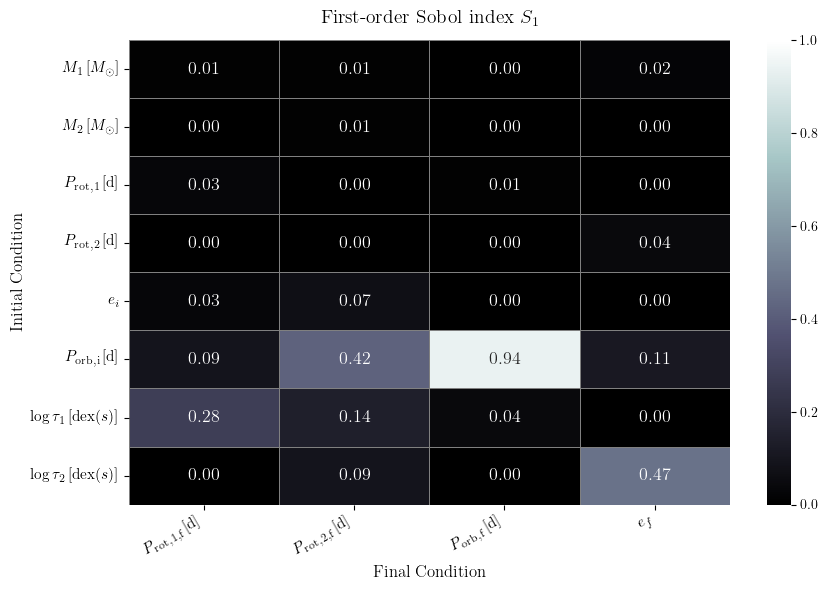

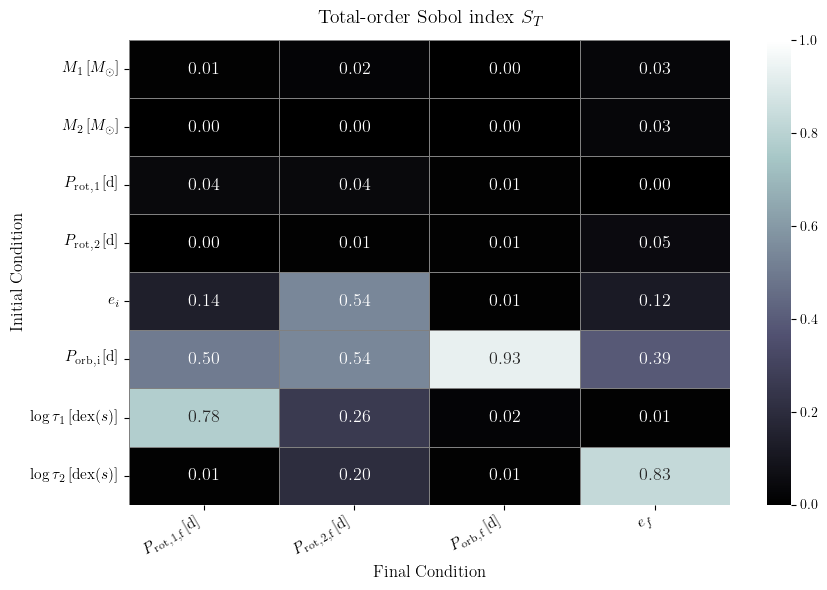

In [15]:
def plot_sensitivity_table(table, title):
    fig, ax = plt.subplots(figsize=(9, 6))
    sn.heatmap(
        table,
        ax=ax,
        annot=True,
        annot_kws={"size": 13},
        fmt=".2f",
        vmin=0,
        vmax=1,
        cmap="bone",
        linewidths=0.5,
        linecolor="gray",
    )
    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel("Final Condition", fontsize=12)
    ax.set_ylabel("Initial Condition", fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=11)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
    plt.tight_layout()
    return fig


fig_s1 = plot_sensitivity_table(table_s1, "First-order Sobol index $S_1$")
fig_sT = plot_sensitivity_table(table_sT, "Total-order Sobol index $S_T$")
plt.show()

### Interpreting the Results

**Reading the heatmap:**

- A value close to **1.0** (dark cell) means that parameter dominates the variance in that output.
- A value close to **0.0** (light cell) means that parameter has little effect on that output.
- Cells where $S_T \gg S_1$ indicate strong parameter interactions.

**Physical interpretation for this binary system:**

- Final rotation periods ($P_{\rm rot}$) are typically sensitive to **initial rotation period** and
  **tidal time lag** of the same body — magnetic braking and tidal torques compete.
- Final orbital period ($P_{\rm orb}$) is most sensitive to **initial orbital period** and **eccentricity**,
  since these set the tidal timescale.
- Final eccentricity is sensitive to the **tidal time lag**, which governs dissipation efficiency.

Parameters with small $S_T$ across all outputs can be fixed at representative values in subsequent
MCMC inference to reduce the dimensionality of the problem.

## 5. Bar Chart of Sensitivity by Parameter

A bar chart makes it easy to rank parameters by their total influence on a specific output.

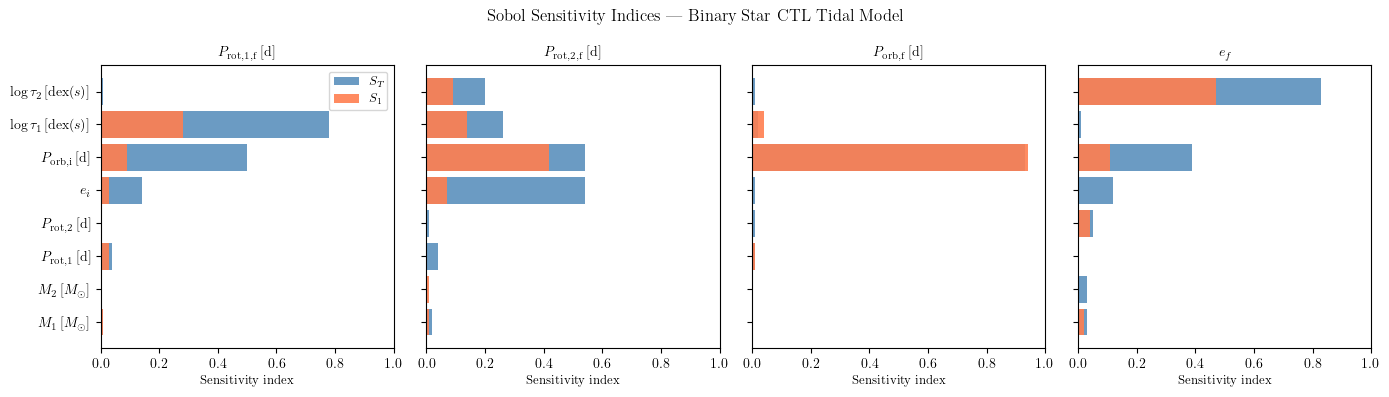

In [16]:
fig, axes = plt.subplots(1, len(labels_out), figsize=(14, 4), sharey=True)

for ax, col in zip(axes, table_sT.columns):
    s1_vals = table_s1[col].values
    sT_vals = table_sT[col].values
    y = np.arange(len(labels_var))

    ax.barh(y, sT_vals, color="steelblue", alpha=0.8, label=r"$S_T$")
    ax.barh(y, s1_vals, color="coral",     alpha=0.9, label=r"$S_1$")
    ax.set_xlim(0, 1)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("Sensitivity index", fontsize=9)
    ax.axvline(0, color="k", lw=0.5)

axes[0].set_yticks(np.arange(len(labels_var)))
axes[0].set_yticklabels(labels_var, fontsize=10)
axes[0].legend(fontsize=9)

fig.suptitle("Sobol Sensitivity Indices — Binary Star CTL Tidal Model", fontsize=12)
plt.tight_layout()
plt.show()

## 6. Using `AnalyzeVplanetModel` (YAML Workflow)

For scripted workflows, `vplanet_inference` provides `AnalyzeVplanetModel`,
which reads a YAML configuration file and wraps the entire sensitivity analysis.

A YAML config file specifies the infile path, fixed and variable inputs,
and outputs — matching the fields we defined manually above.
The bundled example config is at `examples/sensitivity/config.yaml`.

In [17]:
# Show the example config file
config_path = os.path.join(vpi.VPI_DIR, "examples/sensitivity/config.yaml")
with open(config_path) as f:
    print(f.read())

inpath: "../../infiles/stellar_eqtide/ctl"
input_fix:
  "vpl.dStopTime":
    units: "u.Myr"
    true_value: 10
    label: r"age [Myr]"
input_var:
  "primary.dMass":
    units: "u.Msun"
    bounds: (0.6, 1.1)
    label: r"$\rm M_1 [M_{\odot}]$"
  "secondary.dMass":
    units: "u.Msun"
    bounds: (0.6, 1.1)
    label: r"$\rm M_2 [M_{\odot}]$"
  "primary.dRotPeriod":
    units: "u.day"
    bounds: (0.1, 6.0)
    label: r"$\rm P_{rot1,i} [d]$"
  "secondary.dRotPeriod":
    units: "u.day"
    bounds: (0.1, 6.0)
    label: r"$\rm P_{rot2,i} [d]$"
  "secondary.dEcc": 
    units: "u.dimensionless_unscaled"
    bounds: (0.0, 0.5)
    label: r"$e_i$"
  "secondary.dOrbPeriod":
    units: "u.day"
    bounds: (0.1, 12.0)
    label: r"$\rm P_{orb,i} [d]$"
  "primary.dTidalTau":
    units: "u.dex(u.s)"
    bounds: (-4.0, 1.0)
    label: r"$\rm \log\tau_1$ [dex(s)]"
  "secondary.dTidalTau":
    units: "u.dex(u.s)"
    bounds: (-4.0, 1.0)
    label: r"$\rm \log\tau_2$ [dex(s)]"
output:
  "final.primar

In [18]:
# AnalyzeVplanetModel reads the config and automatically:
#   - initialises VplanetModel
#   - sets up the Saltelli problem
#   - builds tables and heatmaps

synth = vpi.AnalyzeVplanetModel(
    config_path,
    outpath="output/sensitivity_yaml",
    verbose=False,
    compute_true=False,   # skip running the true-value model (no true_value in config)
    ncore=mp.cpu_count(),
)

# Run the sensitivity analysis — nsample should be 2^n (use 512-1024 for production)
synth.variance_global_sensitivity(nsample=64, save=True)

# Results are stored as attributes
print("First-order table:")
print(synth.table_s1)

100%|██████████| 1152/1152 [01:46<00:00, 10.77it/s]


First-order table:
                      final.primary.RotPer  final.secondary.RotPer  \
primary.dMass                         0.02                    0.00   
secondary.dMass                       0.00                    0.01   
primary.dRotPeriod                    0.05                    0.00   
secondary.dRotPeriod                  0.00                    0.00   
secondary.dEcc                        0.11                    0.11   
secondary.dOrbPeriod                  0.01                    0.43   
primary.dTidalTau                     0.47                    0.10   
secondary.dTidalTau                   0.00                    0.07   

                      final.secondary.OrbPeriod  final.secondary.Eccentricity  
primary.dMass                              0.00                          0.00  
secondary.dMass                            0.00                          0.00  
primary.dRotPeriod                         0.01                          0.01  
secondary.dRotPeriod          

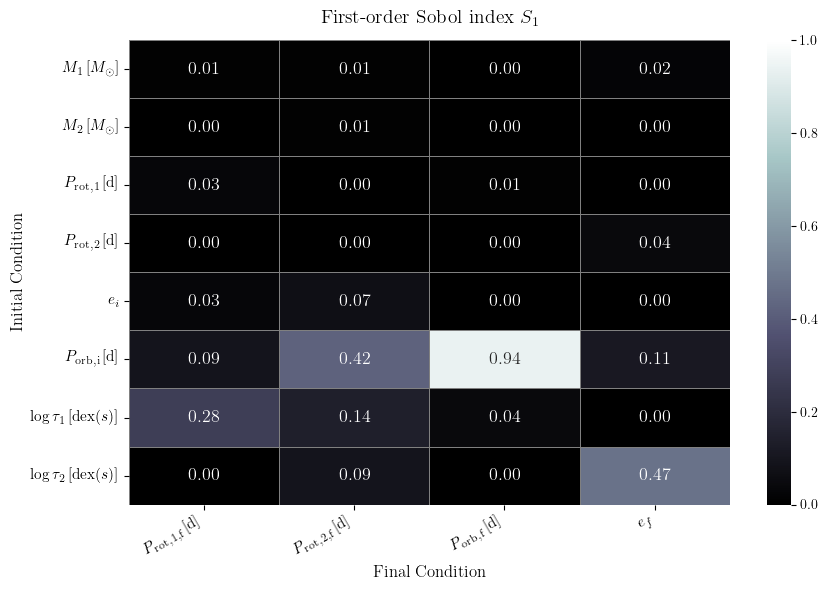

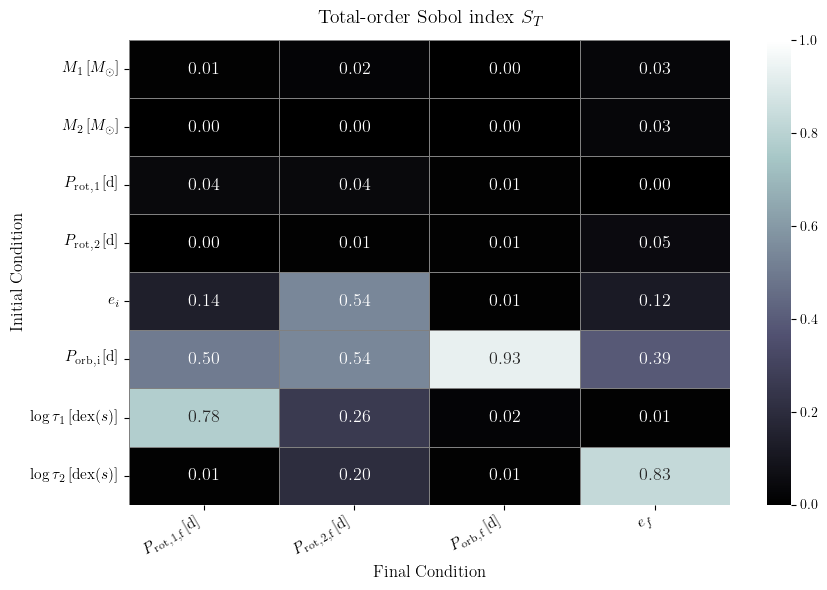

In [21]:
fig_s1 = plot_sensitivity_table(table_s1, "First-order Sobol index $S_1$")
fig_sT = plot_sensitivity_table(table_sT, "Total-order Sobol index $S_T$")
plt.show()

## Summary

| Step | How |
|------|-----|
| Define variable parameters and bounds | `bounds_var = [...]` |
| Generate Saltelli sample | `saltelli.sample(problem, N)` from SALib |
| Evaluate VPLanet at each sample | `mp.Pool.imap(run_model_var, param_values)` |
| Compute Sobol indices | `sobol.analyze(problem, Y_col)` from SALib |
| Visualize | Heatmap via `seaborn.heatmap` or bar chart |
| YAML shortcut | `AnalyzeVplanetModel(config, ...).variance_global_sensitivity(N)` |

**Key takeaways:**

- Use $N \geq 512$ for reliable Sobol estimates (published results typically use 1024–2048)
- Parameters with $S_T < 0.05$ across all outputs can usually be fixed
- $S_T \gg S_1$ signals that a parameter acts mainly through interactions
- GSA is most useful when run on a **short simulation time** (10–100 Myr) to identify
  which parameters matter before running expensive long-period MCMC